<a href="https://colab.research.google.com/github/Tarmuwa/Admn-Dashboard/blob/main/Case%20study%3A%20sentiment%20analysis%20of%20student%E2%80%99s%20complaints%20using%20textblob.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip3 install pandas textblob


In [2]:
from google.colab import files
import pandas as pd
import io
from textblob import TextBlob
import matplotlib.pyplot as plt


In [4]:
# Function to calculate polarity
def get_polarity(text):
    return TextBlob(str(text)).sentiment.polarity

# Classify sentiment
def classify_sentiment(polarity):
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"


In [5]:
uploaded = files.upload()
df = pd.read_csv(io.BytesIO(uploaded['stds_comp.csv']))


Saving stds_comp.csv to stds_comp.csv


In [6]:
# Apply sentiment analysis
df["polarity"] = df["com_std"].apply(get_polarity)

df["sentiment"] = df["polarity"].apply(classify_sentiment)

# Display results
print(df)

# Save results to a new CSV file
df.to_csv("sentiment_results.csv", index=False)


                                               com_std  polarity sentiment
0    I am writing to formally request a review in m...  0.000000   Neutral
1    I request for review of my head and neck exami...  0.000000   Neutral
2                Please I need to re-record my result   0.000000   Neutral
3     With due respect sir, There should be a wrong... -0.041667  Negative
4                                       Wrong markings -0.500000  Negative
..                                                 ...       ...       ...
919  I’m kindly asking for your help to check and r...  0.600000  Positive
920  COMPLAINT REGARDING COS101 RESULT\r\n\r\nDear ...  0.066667  Positive
921  Subject: Complaint Regarding Incorrect Recordi... -0.138889  Negative
922                     I want to verified my results   0.000000   Neutral
923                     I want to verified my results   0.000000   Neutral

[924 rows x 3 columns]


Sentiment Distribution (%)
sentiment
Neutral     42.97
Positive    37.34
Negative    19.70
Name: proportion, dtype: float64
Sentiment Distribution:
sentiment
Neutral     397
Positive    345
Negative    182
Name: count, dtype: int64


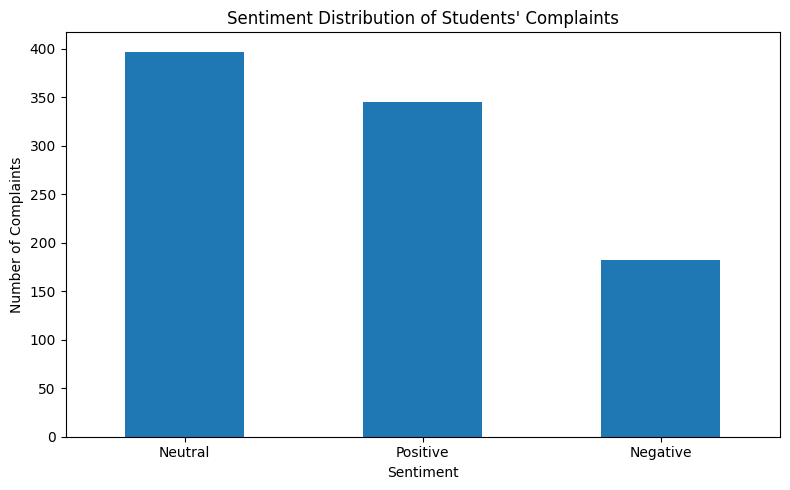

In [7]:
# Calculate sentiment percentages
sentiment_percentage = (
    df["sentiment"].value_counts(normalize=True) * 100
)

print("Sentiment Distribution (%)")
print(sentiment_percentage.round(2))



# Count the number of complaints in each sentiment category
sentiment_counts = df["sentiment"].value_counts()

# Display sentiment counts
print("Sentiment Distribution:")
print(sentiment_counts)

# Create a bar chart
plt.figure(figsize=(8, 5))

sentiment_counts.plot(kind="bar")

plt.title("Sentiment Distribution of Students' Complaints")
plt.xlabel("Sentiment")
plt.ylabel("Number of Complaints")

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()
